In [1]:
%load_ext autoreload
%autoreload 2

import hydra
from hydra.core.global_hydra import GlobalHydra

GlobalHydra.instance().clear()
hydra.initialize(version_base=None, config_path="../conf")
cfg = hydra.compose(config_name="config")

from modules.visualization.plots import plot_positions, plot_pnl, plot_zscore
from modules.data_services.data_utils import load_strategy_result, load_btc_benchmark

interval = cfg.market.interval

test_start = cfg.performance.optimization.start
test_end = cfg.performance.optimization.end

In [2]:
ticker_x = "ETHUSDT"
ticker_y = "UNIUSDT"

result = load_strategy_result(file_name=f"opt_{ticker_x}_{ticker_y}")

In [3]:
result.stats

,gross,net
total_return,-0.0451,-0.0652
cagr,-0.4398,-0.5717
volatility,0.0144,0.0147
volatility_annual,1.3513,1.3717
max_drawdown,-0.2830,-0.2880
win_count,10.0000,10.0000
lose_count,10.0000,10.0000
win_rate,0.5000,0.5000
max_win,0.2947,0.2936
max_lose,-0.3578,-0.3583


In [4]:
result.rolling_window

84

In [5]:
result.data

,ETHUSDT,UNIUSDT,z_score,beta,entry_thr,exit_thr,sl_thr,q_x,q_y,w_x,w_y,signal,position,total_return,total_fees,net_return,total_return_pct,net_return_pct
open_time,,,,,,,,,,,,,,,,,,
2024-02-01 00:00:00,2283.59,6.021,0.824571,1.0,1.143887,0.292073,NaN,0.000000,0.000000,NaN,NaN,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
2024-02-01 01:00:00,2245.19,5.900,0.434286,1.0,1.143887,0.292073,NaN,0.000000,0.000000,NaN,NaN,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
2024-02-01 02:00:00,2260.50,5.999,0.869592,1.0,1.143887,0.292073,NaN,0.000000,0.000000,NaN,NaN,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
2024-02-01 03:00:00,2257.21,5.992,-0.376746,1.0,1.143887,0.292073,NaN,0.000000,0.000000,NaN,NaN,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
2024-02-01 04:00:00,2262.77,6.001,-0.400220,1.0,1.143887,0.292073,NaN,0.000000,0.000000,NaN,NaN,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-02-29 20:00:00,3393.99,11.524,-0.925345,1.0,1.143887,0.292073,2.225541,14.837324,-4401.021037,0.5,0.5,0.0,1.0,-3545.464873,1968.383059,-5513.847932,-0.035455,-0.055138
2024-02-29 21:00:00,3347.74,11.357,-0.986743,1.0,1.143887,0.292073,2.225541,14.837324,-4401.021037,0.5,0.5,0.0,1.0,-3594.209170,1968.383059,-5562.592229,-0.035942,-0.055626
2024-02-29 22:00:00,3322.61,10.977,-0.990957,1.0,1.143887,0.292073,2.225541,14.837324,-4401.021037,0.5,0.5,0.0,1.0,-4893.735223,1968.383059,-6862.118282,-0.048937,-0.068621


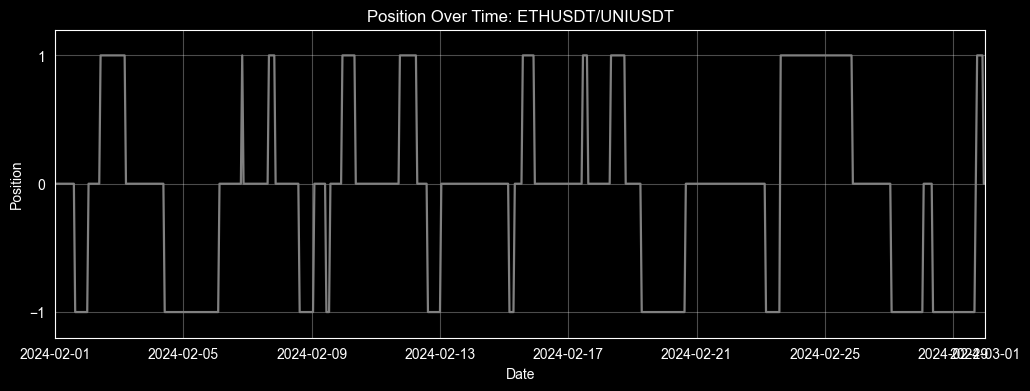

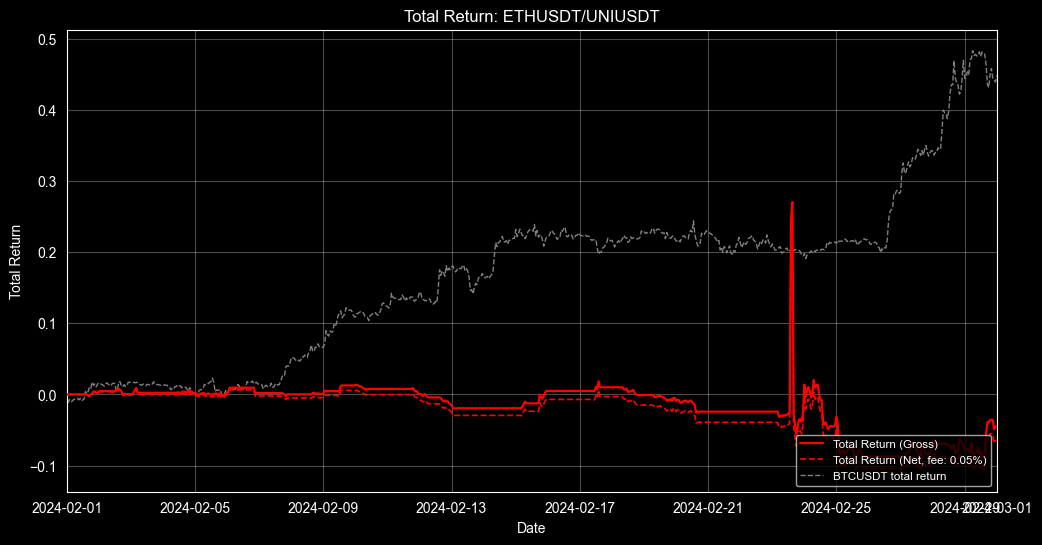

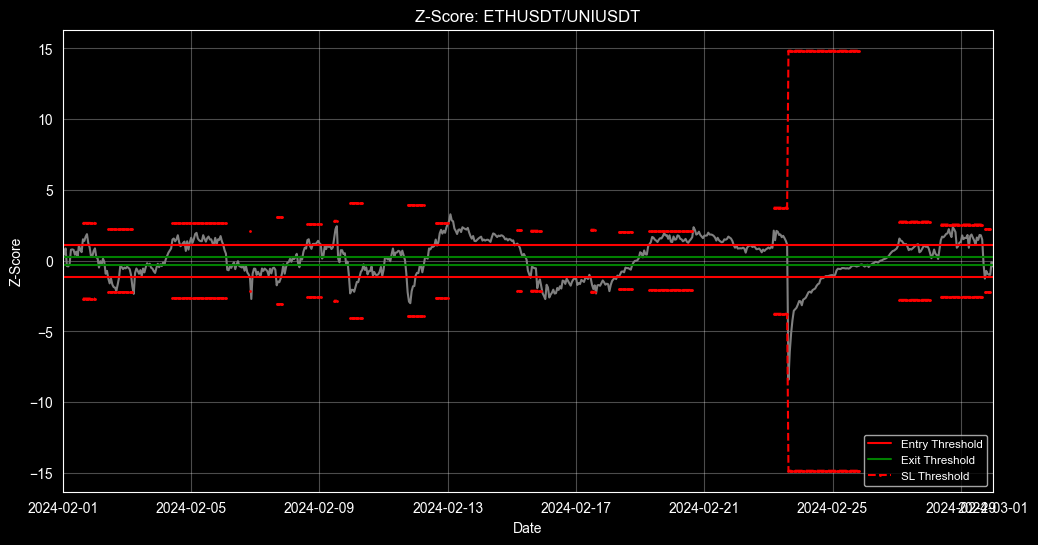

In [6]:
plot_positions(result, show=True)
btc_data = load_btc_benchmark(
    test_start=test_start,
    test_end=test_end,
    interval=interval,
)
plot_pnl(result, btc_data, show=True)
plot_zscore(result, show=True,  sl_thr=True)